In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest
import numpy as np
np.random.seed(5)
from utils.sampling import sample
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs, mrs_without_cv
import seaborn as sns

2024-04-05 17:50:39.114838: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-05 17:50:39.114887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-05 17:50:39.116376: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-05 17:50:39.124393: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-05 17:50:40.070939: W tensorflow/compiler/tf2

In [2]:
def compute_feature_weights_softmax(budget, feature_importance):
    return  np.exp(-feature_importance / budget)

In [3]:
def compute_feature_weights(budget, feature_importance):
    max_importance = np.max(scaled_feature_importance)
    feature_importance = feature_importance / max_importance 
    scaled_feature_importance = scaled_feature_importance * budget
    scaled_feature_importance = 1 - scaled_feature_importance
    return scaled_feature_importance 

In [4]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
N, R = sample(
            "mean_difference",
            df,
            target,
            train_fraction=0.5,
            bias_fraction=0.1,
            columns=columns,
        )
dropped_N = N.copy().reset_index(drop=True)

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [5]:
drop_ids, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", n_repeats=5, random_state=5, drop=20)
_, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", n_repeats=5, random_state=5, drop=20)

In [6]:
# feature_importance[feature_importance < 0] = 0
# feature_importance_cv[feature_importance_cv < 0] = 0

<Axes: >

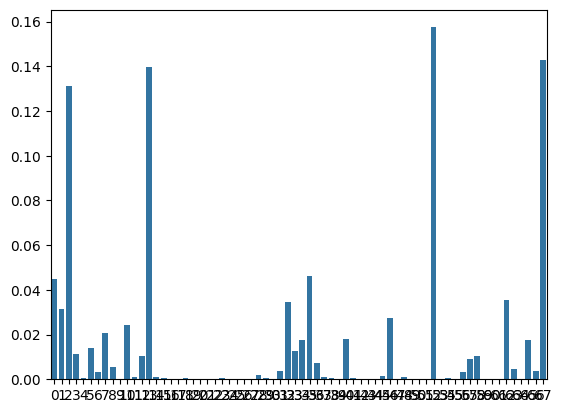

In [7]:
feature_weights = compute_feature_weights_softmax(0.005, feature_importance_cv)
sns.barplot(feature_importance / np.sum(feature_importance))

In [8]:
seed = 5
weight_method = compute_feature_weights_softmax
max_features = "sqrt"
max_depth= None
# budgets = [0, 0.25, 0.5, 0.9]
budgets = [1, 0.1, 0.01, 0.005]
auroc_method = train_feature_weighted_random_forest

In [9]:
for budget in budgets:
    feature_weights = weight_method(budget, feature_importance)
    auroc = compute_test_metrics_fw_mrs(
        dropped_N,
        R,
        columns,
        random_state=seed,
        feature_weights=feature_weights,
        method=auroc_method,
        draw_with_feature_weights=True,
        class_weight="balanced",
        max_features=max_features,
        splitter="feature_weighted_best",
        n_splits_test=10,
        max_depth=max_depth,
    )
    print(f"{budget}: {auroc}")

1: 0.8974720000000002
0.1: 0.8979199999999998
0.01: 0.8979119999999998
0.005: 0.897992


1: 0.5554648659937349\
0.1: 0.5537933170901497\
0.01: 0.525298712147581\
0.005: 0.5

In [10]:
for budget in budgets:
    feature_weights = weight_method(budget, feature_importance_cv)
    auroc = compute_test_metrics_fw_mrs(
        dropped_N,
        R,
        columns,
        random_state=seed,
        feature_weights=feature_weights,
        method=auroc_method,
        draw_with_feature_weights=True,
        class_weight="balanced",
        max_features=max_features,
        splitter="feature_weighted_best",
        n_splits_test=10,
        max_depth=max_depth
    )
    print(f"{budget}: {auroc}")

KeyboardInterrupt: 

1: 0.5554648659937349\
0.1: 0.5538323703445875\
0.01: 0.5211835711799513\
0.005: 0.5

In [ ]:
dropped_N = dropped_N.drop(drop_ids)